In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models
     

In [25]:
df = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")
df_test = pd.read_csv("/kaggle/input/digit-recognizer/test.csv")

In [26]:
df_test.columns

Index(['pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=784)

In [27]:
df.columns

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=785)

In [28]:
X_train = df.drop("label",axis = 1).values
y_train = df['label'].values
X_test = df_test.values

In [29]:
X_train = X_train.astype("float32")/255.0
X_test = X_test.astype("float32")/255.0

In [31]:
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)

In [32]:
y_train_cat = to_categorical(y_train,10)

In [34]:
perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10,activation = "softmax")
])

In [37]:
perceptron.compile(
    optimizer="sgd",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [38]:
history_percep = perceptron.fit(X_train_img,y_train_cat,epochs = 5,batch_size = 32,verbose=1)

Train on 42000 samples
Epoch 1/5
42000/42000 [==============================] - 3s 69us/sample - loss: 0.8812 - accuracy: 0.7924
Epoch 2/5
42000/42000 [==============================] - 2s 52us/sample - loss: 0.4977 - accuracy: 0.8717
Epoch 3/5
42000/42000 [==============================] - 2s 52us/sample - loss: 0.4315 - accuracy: 0.8848
Epoch 4/5
42000/42000 [==============================] - 2s 51us/sample - loss: 0.3987 - accuracy: 0.8916
Epoch 5/5
42000/42000 [==============================] - 3s 64us/sample - loss: 0.3781 - accuracy: 0.8967


In [40]:
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation = "relu"),
    Dense(64,activation = "relu"),
    Dense(10,activation = "softmax")
])

In [41]:
ann.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [42]:
history_ann = ann.fit(X_train_img,y_train_cat,epochs = 5,batch_size = 32,verbose=1)

Train on 42000 samples
Epoch 1/5
42000/42000 [==============================] - 4s 90us/sample - loss: 0.2771 - accuracy: 0.9188
Epoch 2/5
42000/42000 [==============================] - 4s 85us/sample - loss: 0.1154 - accuracy: 0.9650
Epoch 3/5
42000/42000 [==============================] - 3s 82us/sample - loss: 0.0763 - accuracy: 0.9762
Epoch 4/5
42000/42000 [==============================] - 3s 81us/sample - loss: 0.0600 - accuracy: 0.9804
Epoch 5/5
42000/42000 [==============================] - 3s 81us/sample - loss: 0.0460 - accuracy: 0.9848


In [49]:
X_train_cnn= X_train.reshape(-1, 28, 28,1)
X_test_cnn = X_test.reshape(-1, 28, 28,1)

In [46]:
cnn = Sequential([
    Conv2D(32,kernel_size = (3,3),activation = "relu",input_shape = (28,28,1)),
    MaxPooling2D(pool_size = (2,2)),
    Conv2D(64,kernel_size = (3,3),activation = "relu",input_shape = (28,28,1)),
    MaxPooling2D(pool_size = (2,2)),
    Flatten(),
    Dense(128,activation = "relu"),
    Dropout(0.5),
    Dense(10,activation = "softmax")
])

In [48]:
cnn.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [50]:
history_cnn = cnn.fit(X_train_cnn,y_train_cat,epochs = 5,batch_size = 32,verbose=1)

Train on 42000 samples
Epoch 1/5
42000/42000 [==============================] - 26s 613us/sample - loss: 0.2569 - accuracy: 0.9205
Epoch 2/5
42000/42000 [==============================] - 25s 598us/sample - loss: 0.0873 - accuracy: 0.9737
Epoch 3/5
42000/42000 [==============================] - 25s 598us/sample - loss: 0.0647 - accuracy: 0.9808
Epoch 4/5
42000/42000 [==============================] - 25s 601us/sample - loss: 0.0497 - accuracy: 0.9849
Epoch 5/5
42000/42000 [==============================] - 25s 602us/sample - loss: 0.0424 - accuracy: 0.9873


In [52]:

def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()

KeyError: 'val_accuracy'

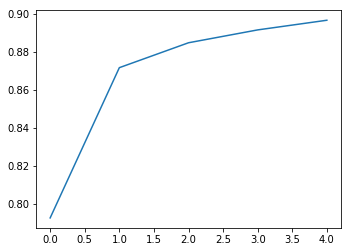

In [53]:
plot_training(history_percep,"Perceptron")

In [64]:
def show_side_by_side(models, model_names, X, X_cnn, n=5):
    import numpy as np
    import matplotlib.pyplot as plt

    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))

    for i, idx in enumerate(idxs):
        # 🔹 Show Image
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title("Input Image")

        preds = []
        for model, name in zip(models, model_names):

            input_shape = model.input_shape

            # 🔥 AUTO DETECT MODEL TYPE
            if len(input_shape) == 4:
                # CNN → (None, 28, 28, 1)
                pred = np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1)))

            elif len(input_shape) == 3:
                # ANN → (None, 28, 28)
                pred = np.argmax(model.predict(X[idx].reshape(1, 28, 28)))

            elif len(input_shape) == 2:
                # Flat models → (None, 784)
                pred = np.argmax(model.predict(X[idx].reshape(1, -1)))

            else:
                raise ValueError("Unknown model input shape")

            preds.append(pred)

        # 🔹 Show Predictions
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{name}: {pred}" for name, pred in zip(model_names, preds)))

    plt.tight_layout()
    plt.show()

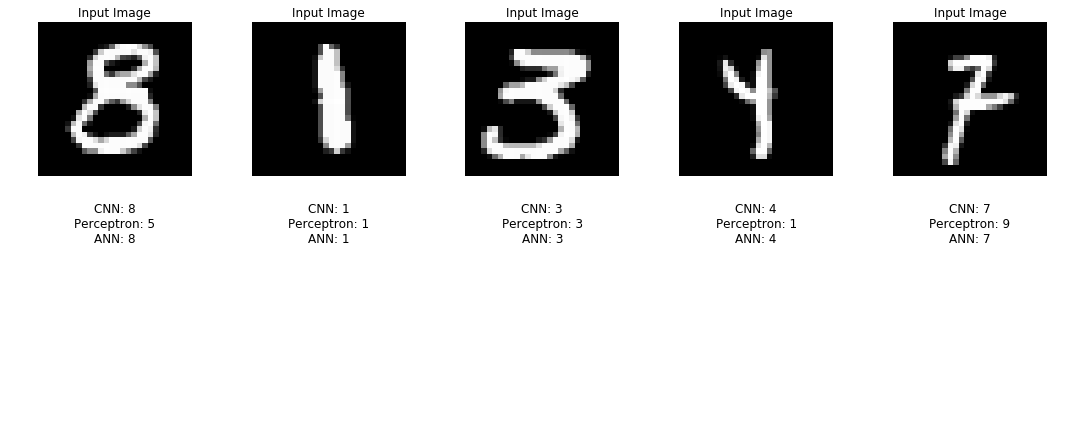

In [65]:
models = [cnn, perceptron, ann]
model_names = ["CNN", "Perceptron", "ANN"]

show_side_by_side(models, model_names, X_test, X_test_img, n=5)